### 1.Імпорт бібліотек і спільні функції

In [100]:
import os
import random
import time
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

In [101]:
def load_dataset(filename):
    with open(filename, "r", encoding="utf-8") as file:
        lines = file.readlines()

    capacity = int(lines[0].strip())
    items = []

    for line in lines[1:]:
        weight, price = map(int, line.strip().split())
        items.append((weight, price))

    return capacity, items


def weight(solution, items):
    return sum(solution[i] * items[i][0] for i in range(len(solution)))


def value(solution, items):
    return sum(solution[i] * items[i][1] for i in range(len(solution)))


def repair(solution, items, capacity):
    while weight(solution, items) > capacity:
        selected = [i for i, gene in enumerate(solution) if gene == 1]
        if not selected:
            break
        index = random.choice(selected)
        solution[index] = 0
    return solution

### 2. Генерація тестових даних

In [102]:
def generate_items(n, min_weight=10, max_weight=99, min_price=10, max_price=99):
    items = []
    for _ in range(n):
        item_weight = random.randint(min_weight, max_weight)
        item_price = random.randint(min_price, max_price)
        items.append((item_weight, item_price))
    return items


def generate_capacity(items):
    total_weight = sum(w for w, _ in items)
    capacity = int(total_weight * random.uniform(0.3, 0.6))

    min_item_weight = min(w for w, _ in items)
    if capacity < min_item_weight:
        capacity = min_item_weight

    return capacity


def save_dataset(filename, capacity, items):
    with open(filename, "w", encoding="utf-8") as file:
        file.write(f"{capacity}\n")
        for item_weight, item_price in items:
            file.write(f"{item_weight} {item_price}\n")


def create_datasets():
    random.seed(42)

    folder_name = "Datasets"
    os.makedirs(folder_name, exist_ok=True)

    sizes = [20, 30, 40, 50, 70, 100]
    files_per_size = 2
    created_files = []
    file_number = 1

    for size in sizes:
        for _ in range(files_per_size):
            items = generate_items(size)
            capacity = generate_capacity(items)

            filename = os.path.join(folder_name, f"Data{file_number:02d}.txt")
            save_dataset(filename, capacity, items)
            created_files.append(filename)

            file_number += 1

    return created_files

In [103]:
files = create_datasets()

print("Створені тестові файли:")
for filename in files:
    print(filename)

Створені тестові файли:
Datasets\Data01.txt
Datasets\Data02.txt
Datasets\Data03.txt
Datasets\Data04.txt
Datasets\Data05.txt
Datasets\Data06.txt
Datasets\Data07.txt
Datasets\Data08.txt
Datasets\Data09.txt
Datasets\Data10.txt
Datasets\Data11.txt
Datasets\Data12.txt


### 3.Реалізація генетичного алгоритму

In [104]:
random.seed(42)

def fitness(chromosome, items, capacity):
    total_weight = weight(chromosome, items)
    total_value = value(chromosome, items)

    if total_weight > capacity:
        return 0
    return total_value


def generate_chromosome(n, items, capacity):
    chromosome = [random.randint(0, 1) for _ in range(n)]
    return repair(chromosome, items, capacity)


def initial_population(population_size, n, items, capacity):
    return [generate_chromosome(n, items, capacity) for _ in range(population_size)]


def tournament_selection(population, items, capacity, tournament_size=3):
    candidates = random.sample(population, tournament_size)
    return max(candidates, key=lambda chromosome: fitness(chromosome, items, capacity))[:]


def single_point_crossover(parent1, parent2):
    if len(parent1) < 2:
        return parent1[:], parent2[:]

    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2


def mutate(chromosome, mutation_rate):
    for i in range(len(chromosome)):
        if random.random() < mutation_rate:
            chromosome[i] = 1 - chromosome[i]
    return chromosome


def genetic_algorithm(
    items,
    capacity,
    population_size=100,
    generations=200,
    crossover_rate=0.8,
    mutation_rate=0.02,
    tournament_size=3,
    elite_size=1,
    histogram_step=50
):
    n = len(items)
    population = initial_population(population_size, n, items, capacity)

    best_history = []
    average_history = []
    histogram_data = {}

    start_time = time.time()

    for generation in range(generations):
        population.sort(key=lambda chromosome: fitness(chromosome, items, capacity), reverse=True)

        current_best = fitness(population[0], items, capacity)
        current_average = sum(fitness(chromosome, items, capacity) for chromosome in population) / population_size

        best_history.append(current_best)
        average_history.append(current_average)

        if generation % histogram_step == 0 or generation == generations - 1:
            histogram_data[generation] = [
                fitness(chromosome, items, capacity) for chromosome in population
            ]

        new_population = [population[i][:] for i in range(elite_size)]

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, items, capacity, tournament_size)
            parent2 = tournament_selection(population, items, capacity, tournament_size)

            if random.random() < crossover_rate:
                child1, child2 = single_point_crossover(parent1, parent2)
            else:
                child1, child2 = parent1[:], parent2[:]

            child1 = mutate(child1, mutation_rate)
            child2 = mutate(child2, mutation_rate)

            child1 = repair(child1, items, capacity)
            child2 = repair(child2, items, capacity)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    end_time = time.time()

    best_solution = max(population, key=lambda chromosome: fitness(chromosome, items, capacity))

    return {
        "solution": best_solution,
        "value": value(best_solution, items),
        "weight": weight(best_solution, items),
        "time": end_time - start_time,
        "best_history": best_history,
        "average_history": average_history,
        "histogram_data": histogram_data
    }

In [105]:
def run_genetic_algorithm_for_all_files(file_list):
    results = []

    for filename in file_list:
        capacity, items = load_dataset(filename)
        result = genetic_algorithm(items, capacity)

        results.append({
            "file": os.path.basename(filename),
            "capacity": capacity,
            "n": len(items),
            "value": result["value"],
            "weight": result["weight"],
            "time": result["time"],
            "solution": result["solution"],
            "best_history": result["best_history"],
            "average_history": result["average_history"],
            "histogram_data": result["histogram_data"]
        })

    return results

#### 3.1 Бонусне тестування генетичного алгоритму на двох текстових файлах

In [106]:
ga_results = run_genetic_algorithm_for_all_files(files)

def test_genetic_algorithm_on_two_files(file_list):
    selected_files = [file_list[0], file_list[3]]
    bonus_results = []

    print("\nТестування генетичного алгоритму на 2 файлах")
    print("-" * 64)
    print(
        f"{'Файл':<12}"
        f"{'n':<8}"
        f"{'Містк.':<10}"
        f"{'Цінність':<12}"
        f"{'Вага':<10}"
        f"{'Час (сек)':<12}"
    )

    for filename in selected_files:
        capacity, items = load_dataset(filename)
        result = genetic_algorithm(items, capacity)

        row = {
            "file": os.path.basename(filename),
            "n": len(items),
            "capacity": capacity,
            "value": result["value"],
            "weight": result["weight"],
            "time": result["time"],
            "solution": result["solution"]
        }
        bonus_results.append(row)

        print(
            f"{row['file']:<12}"
            f"{row['n']:<8}"
            f"{row['capacity']:<10}"
            f"{row['value']:<12}"
            f"{row['weight']:<10}"
            f"{row['time']:<12.6f}"
        )

    return bonus_results


bonus_ga_results = test_genetic_algorithm_on_two_files(files)


Тестування генетичного алгоритму на 2 файлах
----------------------------------------------------------------
Файл        n       Містк.    Цінність    Вага      Час (сек)   
Data01.txt  20      322       651         317       1.144915    
Data04.txt  30      1051      1228        1046      1.475926    


In [107]:
print("\nРезультати генетичного алгоритму для всіх наборів даних")
print("-" * 64)

print(
    f"{'Файл':<12}"
    f"{'n':<8}"
    f"{'Містк.':<10}"
    f"{'Цінність':<12}"
    f"{'Вага':<10}"
    f"{'Час (сек)':<12}"
)

for result in ga_results:
    print(
        f"{result['file']:<12}"
        f"{result['n']:<8}"
        f"{result['capacity']:<10}"
        f"{result['value']:<12}"
        f"{result['weight']:<10}"
        f"{result['time']:<12.6f}"
    )


Результати генетичного алгоритму для всіх наборів даних
----------------------------------------------------------------
Файл        n       Містк.    Цінність    Вага      Час (сек)   
Data01.txt  20      322       651         317       1.222352    
Data02.txt  20      554       790         541       1.139450    
Data03.txt  30      958       1445        955       1.530457    
Data04.txt  30      1051      1228        1046      1.518538    
Data05.txt  40      1197      1844        1197      1.901909    
Data06.txt  40      1234      1890        1228      1.833724    
Data07.txt  50      1012      1911        1012      2.312667    
Data08.txt  50      1469      2061        1464      2.280784    
Data09.txt  70      1298      2136        1297      3.284147    
Data10.txt  70      1521      2872        1521      3.140939    
Data11.txt  100     2775      4295        2771      4.221279    
Data12.txt  100     3453      4423        3449      4.218602    


### 4. Візуалізація збіжності генетичного алгоритму

In [108]:
def animate_genetic_process(histogram_data, best_history, average_history, dataset_name,
                            output_path="genetic_animation.gif"):
    generations = list(histogram_data.keys())
    histogram_values = list(histogram_data.values())

    max_hist_value = max(max(values) for values in histogram_values)
    max_curve_value = max(max(best_history), max(average_history))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    def update(frame_index):
        generation = generations[frame_index]
        values = histogram_values[frame_index]

        ax1.clear()
        ax1.bar(range(len(values)), values)
        ax1.set_title(f"Гістограма популяції\nІтерація {generation}")
        ax1.set_xlabel("Номер хромосоми")
        ax1.set_ylabel("Значення цільової функції")
        ax1.set_ylim(0, max_hist_value * 1.1)
        ax1.grid(True, axis="y", alpha=0.3)

        ax2.clear()
        ax2.plot(best_history[:generation + 1], label="Найкраще значення")
        ax2.plot(average_history[:generation + 1], label="Середнє значення")
        ax2.set_title("Графік збіжності")
        ax2.set_xlabel("Номер ітерації")
        ax2.set_ylabel("Значення цільової функції")
        ax2.set_xlim(0, len(best_history))
        ax2.set_ylim(0, max_curve_value * 1.1)
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        fig.suptitle(f"Динаміка збіжності генетичного алгоритму ({dataset_name})", fontsize=14)

    animation = FuncAnimation(
        fig,
        update,
        frames=len(generations),
        repeat=True
    )

    animation.save(output_path, writer=PillowWriter(fps=2))
    plt.close(fig)

    print("Збережено", output_path)

In [109]:
test_file = files[6]
capacity, items = load_dataset(test_file)

ga_result = genetic_algorithm(
    items,
    capacity,
    histogram_step=10
)

animate_genetic_process(
    ga_result["histogram_data"],
    ga_result["best_history"],
    ga_result["average_history"],
    test_file,
    output_path="ga_two_plots_7.gif"
)

Збережено ga_two_plots_7.gif


### 5. Реалізація алгоритму імітації відпалу

In [110]:
def random_solution(n, items, capacity):
    solution = [random.randint(0, 1) for _ in range(n)]
    return repair(solution, items, capacity)


def neighbor_solution(solution, items, capacity):
    neighbor = solution[:]

    changes = random.randint(1, 2)
    indices = random.sample(range(len(solution)), changes)

    for index in indices:
        neighbor[index] = 1 - neighbor[index]

    return repair(neighbor, items, capacity)


def simulated_annealing(
    items,
    capacity,
    initial_temp=1000.0,
    cooling_rate=0.97,
    min_temp=0.1,
    max_iterations=500
):
    n = len(items)

    current = random_solution(n, items, capacity)
    best = current[:]

    current_value = value(current, items)
    best_value = current_value

    temperature = initial_temp

    best_history = []
    current_history = []

    start_time = time.time()

    iteration = 0
    while temperature > min_temp and iteration < max_iterations:
        neighbor = neighbor_solution(current, items, capacity)

        neighbor_value = value(neighbor, items)
        delta = neighbor_value - current_value

        if delta > 0:
            current = neighbor
            current_value = neighbor_value
        else:
            probability = math.exp(delta / temperature)
            if random.random() < probability:
                current = neighbor
                current_value = neighbor_value

        if current_value > best_value:
            best = current[:]
            best_value = current_value

        best_history.append(best_value)
        current_history.append(current_value)

        temperature *= cooling_rate
        iteration += 1

    end_time = time.time()

    return {
        "solution": best,
        "value": value(best, items),
        "weight": weight(best, items),
        "time": end_time - start_time,
        "best_history": best_history,
        "current_history": current_history
    }


def plot_annealing_convergence(best_history, current_history, dataset_name):
    plt.figure(figsize=(10, 6))
    plt.plot(best_history, label="Найкраще значення")
    plt.plot(current_history, label="Поточне значення")
    plt.xlabel("Номер ітерації")
    plt.ylabel("Значення цільової функції")
    plt.title(f"Графік збіжності імітації відпалу ({dataset_name})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [111]:
def run_simulated_annealing_for_all_files(file_list):
    results = []

    for filename in file_list:
        capacity, items = load_dataset(filename)
        result = simulated_annealing(items, capacity)

        results.append({
            "file": os.path.basename(filename),
            "capacity": capacity,
            "n": len(items),
            "value": result["value"],
            "weight": result["weight"],
            "time": result["time"],
            "solution": result["solution"],
            "best_history": result["best_history"],
            "current_history": result["current_history"]
        })

    return results

In [112]:
sa_results = run_simulated_annealing_for_all_files(files)

print("Результати імітації відпалу для всіх наборів даних\n")

print(
    f"{'Файл':<12}"
    f"{'n':<8}"
    f"{'Містк.':<10}"
    f"{'Цінність':<12}"
    f"{'Вага':<10}"
    f"{'Час (сек)':<12}"
)

print("-" * 64)

for result in sa_results:
    print(
        f"{result['file']:<12}"
        f"{result['n']:<8}"
        f"{result['capacity']:<10}"
        f"{result['value']:<12}"
        f"{result['weight']:<10}"
        f"{result['time']:<12.6f}"
    )

Результати імітації відпалу для всіх наборів даних

Файл        n       Містк.    Цінність    Вага      Час (сек)   
----------------------------------------------------------------
Data01.txt  20      322       651         317       0.008761    
Data02.txt  20      554       763         538       0.007332    
Data03.txt  30      958       1343        956       0.009018    
Data04.txt  30      1051      1194        1051      0.006927    
Data05.txt  40      1197      1775        1190      0.008399    
Data06.txt  40      1234      1823        1224      0.009828    
Data07.txt  50      1012      1718        1009      0.010440    
Data08.txt  50      1469      1867        1450      0.011209    
Data09.txt  70      1298      1900        1286      0.014132    
Data10.txt  70      1521      2600        1499      0.013840    
Data11.txt  100     2775      3944        2763      0.019291    
Data12.txt  100     3453      3997        3390      0.015249    


### 6. Тестування та порівняння алгоритмів

In [113]:
def combine_results(ga_results, sa_results):
    results = []

    for ga_result, sa_result in zip(ga_results, sa_results):
        results.append({
            "file": ga_result["file"],
            "n": ga_result["n"],
            "capacity": ga_result["capacity"],
            "ga_value": ga_result["value"],
            "ga_weight": ga_result["weight"],
            "ga_time": ga_result["time"],
            "sa_value": sa_result["value"],
            "sa_weight": sa_result["weight"],
            "sa_time": sa_result["time"]
        })

    return results


def print_results_table(results):
    print(
        f"{'Файл':<10}"
        f"{'n':<8}"
        f"{'Містк.':<10}"
        f"{'GA цінн.':<12}"
        f"{'GA вага':<12}"
        f"{'GA час':<12}"
        f"{'SA цінн.':<12}"
        f"{'SA вага':<12}"
        f"{'SA час':<12}"
    )

    for row in results:
        print(
            f"{row['file']:<10}"
            f"{row['n']:<8}"
            f"{row['capacity']:<10}"
            f"{row['ga_value']:<12}"
            f"{row['ga_weight']:<12}"
            f"{row['ga_time']:<12.6f}"
            f"{row['sa_value']:<12}"
            f"{row['sa_weight']:<12}"
            f"{row['sa_time']:<12.6f}"
        )


def print_summary(results):
    average_ga_value = sum(row["ga_value"] for row in results) / len(results)
    average_sa_value = sum(row["sa_value"] for row in results) / len(results)

    average_ga_time = sum(row["ga_time"] for row in results) / len(results)
    average_sa_time = sum(row["sa_time"] for row in results) / len(results)

    print()
    print("Середнє значення цільової функції для генетичного алгоритму:", round(average_ga_value, 2))
    print("Середнє значення цільової функції для імітації відпалу:", round(average_sa_value, 2))
    print("\n")
    print("Середній час роботи генетичного алгоритму:", round(average_ga_time, 6), "сек")
    print("Середній час роботи імітації відпалу:", round(average_sa_time, 6), "сек")
    print("\n")
    
    if average_ga_value > average_sa_value:
        print("За якістю розв’язку кращий генетичний алгоритм.")
    else:
        print("За якістю розв’язку кращий алгоритм імітації відпалу.")

    if average_ga_time < average_sa_time:
        print("За швидкодією кращий генетичний алгоритм.")
    else:
        print("За швидкодією кращий алгоритм імітації відпалу.")


def plot_comparison(results):
    files = [row["file"] for row in results]
    ga_values = [row["ga_value"] for row in results]
    sa_values = [row["sa_value"] for row in results]

    ga_times = [row["ga_time"] for row in results]
    sa_times = [row["sa_time"] for row in results]

    plt.figure(figsize=(12, 6))
    plt.plot(files, ga_values, marker="o", label="Генетичний алгоритм")
    plt.plot(files, sa_values, marker="o", label="Імітація відпалу")
    plt.xlabel("Тестові файли")
    plt.ylabel("Значення цільової функції")
    plt.title("Порівняння алгоритмів за значенням цільової функції")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(files, ga_times, marker="o", label="Генетичний алгоритм")
    plt.plot(files, sa_times, marker="o", label="Імітація відпалу")
    plt.xlabel("Тестові файли")
    plt.ylabel("Час роботи, сек")
    plt.title("Порівняння алгоритмів за часом роботи")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Файл      n       Містк.    GA цінн.    GA вага     GA час      SA цінн.    SA вага     SA час      
Data01.txt20      322       651         317         1.222352    651         317         0.008761    
Data02.txt20      554       790         541         1.139450    763         538         0.007332    
Data03.txt30      958       1445        955         1.530457    1343        956         0.009018    
Data04.txt30      1051      1228        1046        1.518538    1194        1051        0.006927    
Data05.txt40      1197      1844        1197        1.901909    1775        1190        0.008399    
Data06.txt40      1234      1890        1228        1.833724    1823        1224        0.009828    
Data07.txt50      1012      1911        1012        2.312667    1718        1009        0.010440    
Data08.txt50      1469      2061        1464        2.280784    1867        1450        0.011209    
Data09.txt70      1298      2136        1297        3.284147    1900        1286        0.0

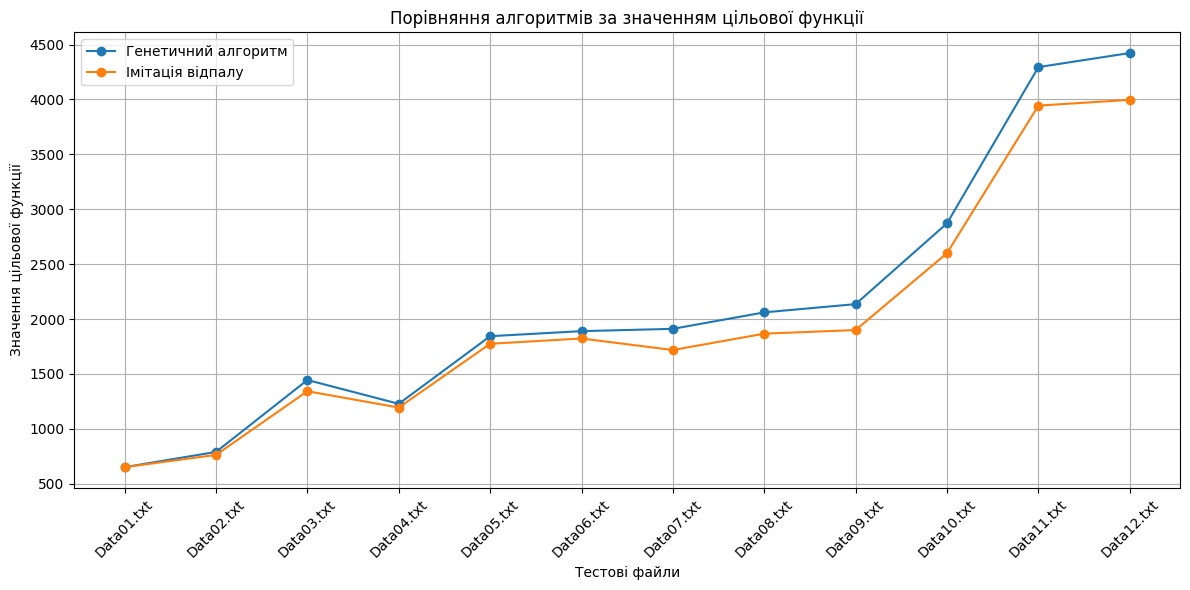

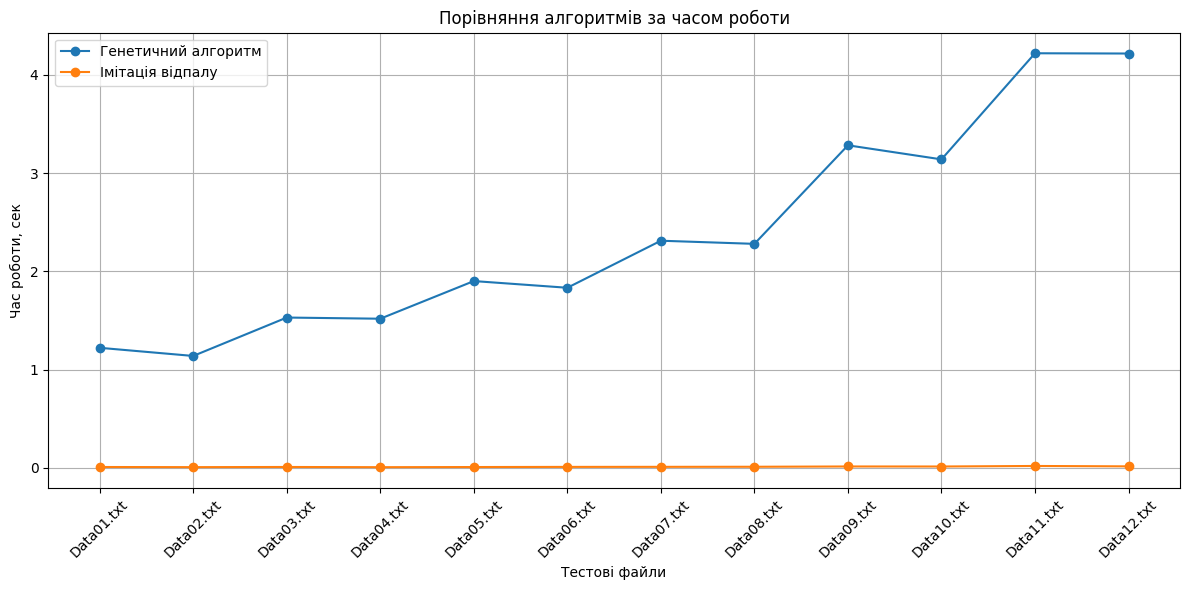

In [114]:
comparison_results = combine_results(ga_results, sa_results)

print_results_table(comparison_results)
print_summary(comparison_results)
plot_comparison(comparison_results)